In [1]:
import coffea
from coffea import util
import numpy as np
import pandas as pd
import itertools
import os
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")


## analysis categories

In [2]:
# analysis categories #
# ttagcats = ["AT&Pt", "at", "pret", "0t", "1t", ">=1t", "2t", ">=0t"]
ttagcats = ["at", "pret", "2t"]
btagcats = ["0b", "1b", "2b"]
ycats = ['cen', 'fwd']

anacats = [ t+b+y for t,b,y in itertools.product( ttagcats, btagcats, ycats) ]
label_dict = {i: label for i, label in enumerate(anacats)}
label_to_int_dict = {label: i for i, label in enumerate(anacats)}
print(label_dict)
# print(label_to_int_dict)

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


In [3]:
# label_dict

## directories for saving files

In [4]:
directories = [
    '../plots/images/png/mistagRate/2016all',
    '../plots/images/png/mistagRate/2016APV',
    '../plots/images/png/mistagRate/2016',
    '../plots/images/png/mistagRate/2017',
    '../plots/images/png/mistagRate/2018',
    '../plots/images/pdf/mistagRate/2016all',
    '../plots/images/pdf/mistagRate/2016APV',
    '../plots/images/pdf/mistagRate/2016',
    '../plots/images/pdf/mistagRate/2017',
    '../plots/images/pdf/mistagRate/2018',
    '../plots/images/png/mistagRateQCD/2016all',
    '../plots/images/png/mistagRateQCD/2016APV',
    '../plots/images/png/mistagRateQCD/2016',
    '../plots/images/png/mistagRateQCD/2017',
    '../plots/images/png/mistagRateQCD/2018',
    '../plots/images/pdf/mistagRateQCD/2016all',
    '../plots/images/pdf/mistagRateQCD/2016APV',
    '../plots/images/pdf/mistagRateQCD/2016',
    '../plots/images/pdf/mistagRateQCD/2017',
    '../plots/images/pdf/mistagRateQCD/2018',
    '../data/corrections/backgroundEstimate'
]

for path in directories:
    if not os.path.exists(path):
        os.makedirs(path)
        




## load coffea files

In [5]:
useDeepAK8 = False
useOldHTcut = False
useOldTaggers = False
useSysts = False
runQCD = True
IOV = '2016APV'

deepak8str = ''
oldHTstr = ''
oldTaggerstr = ''
noSyst = '_noSyst'

if useDeepAK8:
    deepak8str = '_DeepAK8'
if useOldHTcut:
    oldHTstr = '_oldHTcut'
if useOldTaggers:
    oldTaggerstr = '_oldBTag'
if useSysts:
    noSyst = ''
    
coffea_dir = '../outputs/' #'../outputs/FromMeg/AC_coffeafiles/'
coffeaFiles = {
    "JetHT":{
        "2016APV": {
            "B": coffea_dir+'JetHT_2016APVB'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "C": coffea_dir+'JetHT_2016APVC'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "D": coffea_dir+'JetHT_2016APVD'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "E": coffea_dir+'JetHT_2016APVE'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "F": coffea_dir+'JetHT_2016APVF'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "F": coffea_dir+'JetHT_2016F'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "G": coffea_dir+'JetHT_2016G'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "H": coffea_dir+'JetHT_2016H'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": {
            "B": coffea_dir+'JetHT_2017B'+deepak8str+'.coffea',
            "C": coffea_dir+'JetHT_2017C'+deepak8str+'.coffea',
            "D": coffea_dir+'JetHT_2017D'+deepak8str+'.coffea',
            "E": coffea_dir+'JetHT_2017E'+deepak8str+'.coffea',
            "F": coffea_dir+'JetHT_2017F'+deepak8str+'.coffea'
        },
        "2018": {
            "A": coffea_dir+'JetHT_2018A'+deepak8str+'.coffea',
            "B": coffea_dir+'JetHT_2018B'+deepak8str+'.coffea',
            "C": coffea_dir+'JetHT_2018C'+deepak8str+'.coffea',
            "D": coffea_dir+'JetHT_2018D'+deepak8str+'.coffea'
        }
    },
    
    "TTbar": {
        "2016APV": {
            "700to1000": coffea_dir+'TTbar_2016APV_700to1000'+deepak8str+oldHTstr+oldTaggerstr+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2016APV_1000toInf'+deepak8str+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "700to1000": coffea_dir+'TTbar_2016_700to1000'+deepak8str+oldHTstr+oldTaggerstr+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2016_1000toInf'+deepak8str+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": {
            "700to1000": coffea_dir+'TTbar_2017_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2017_1000toInf_noSyst'+deepak8str+'.coffea'
        },
        "2018": {
            "700to1000": coffea_dir+'TTbar_2018_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2018_1000toInf_noSyst'+deepak8str+'.coffea'
        }
    },
    
    "QCD": {
        "2016APV": {
            "800to1000": coffea_dir+'QCD_2016APV_800to1000'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016APV_1000to1400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016APV_1400to1800'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016APV_1800to2400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016APV_2400to3200'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016APV_3200toInf'+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "800to1000": coffea_dir+'QCD_2016_800to1000'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016_1000to1400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016_1400to1800'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016_1800to2400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016_2400to3200'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016_3200toInf'+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": coffea_dir+'QCD_2017_noSyst.coffea',
        "2018": coffea_dir+'QCD_2018_noSyst.coffea'
    }
}

In [6]:
# Output = util.load(coffeaFiles['JetHT']['2016APV']['B'])
# Output['cutflow']

## manual jet $p$ bins

In [7]:
# pbins = numerator.axes['jetp'].centers - numerator.axes['jetp'].widths/2
pbins = np.array([ 400.,  500.,  600.,  800., 1000., 1500., 2000., 3000., 7000.])


## scale factors

In [8]:
# https://twiki.cern.ch/twiki/bin/viewauth/CMS/PdmVAnalysisSummaryTable
luminosity = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2017": 41530.,
    "2018": 59740.
}

ttbar_xs = {}
ttbar_xs["700to1000"] = 831.76 * (0.09210)
ttbar_xs["1000toInf"] = 831.76 * (0.02474)
toptag_sf = 1.0
toptag_kf = 1.0

qcd_xs = 1370000000.0 

## calculate mistag rate

In [9]:
if runQCD:
    qcd = {}
    qcd['800to1000'] = util.load(coffeaFiles['QCD'][IOV]['800to1000'])
    qcd['1000to1400'] = util.load(coffeaFiles['QCD'][IOV]['1000to1400'])
    qcd['1400to1800'] = util.load(coffeaFiles['QCD'][IOV]['1400to1800'])
    qcd['1800to2400'] = util.load(coffeaFiles['QCD'][IOV]['1800to2400'])
    qcd['2400to3200'] = util.load(coffeaFiles['QCD'][IOV]['2400to3200'])
    qcd['3200toInf'] = util.load(coffeaFiles['QCD'][IOV]['3200toInf'])

    qcd_SF = {}
    qcd_SF['800to1000'] = luminosity[IOV] * qcd_xs / qcd['800to1000']['cutflow']['sumw']
    qcd_SF['1000to1400'] = luminosity[IOV] * qcd_xs / qcd['1000to1400']['cutflow']['sumw']
    qcd_SF['1400to1800'] = luminosity[IOV] * qcd_xs / qcd['1400to1800']['cutflow']['sumw']
    qcd_SF['1800to2400'] = luminosity[IOV] * qcd_xs / qcd['1800to2400']['cutflow']['sumw']
    qcd_SF['2400to3200'] = luminosity[IOV] * qcd_xs / qcd['2400to3200']['cutflow']['sumw']
    qcd_SF['3200toInf'] = luminosity[IOV] * qcd_xs / qcd['3200toInf']['cutflow']['sumw']
    save_csv_filename = f'QCD_mistag_rate_{IOV}.csv'
else:
    ttbar_700to1000 = util.load(coffeaFiles['TTbar'][IOV]['700to1000'])
    ttbar_1000toInf = util.load(coffeaFiles['TTbar'][IOV]['1000toInf'])
    ttbar_evts = {}
    ttbar_evts["700to1000"] = ttbar_700to1000['cutflow']['sumw']
    ttbar_evts["1000toInf"] = ttbar_1000toInf['cutflow']['sumw']

    ttbar_SF = {}
    ttbar_SF["700to1000"] = luminosity[IOV] * ttbar_xs["700to1000"] / ttbar_evts["700to1000"]
    ttbar_SF["1000toInf"] = luminosity[IOV] * ttbar_xs["1000toInf"] / ttbar_evts["1000toInf"]
    save_csv_filename = f'mistag_rate_{IOV}.csv'

    jetht_files = []

    for era, file in coffeaFiles['JetHT'][IOV].items():
        if os.path.isfile(file):
            print('loading', file)
            jetht_files.append(util.load(file))

mistag_rate_dict = {}
mistag_rate_dict_all = {}
mistag_rate_dict["jetp bins"] = pbins
mistag_rate_dict_all["jetp bins"] = pbins

for i, label in label_dict.items():

    if runQCD:
        qcd_numerator = qcd['800to1000']['numerator'][{'anacat':i}].values() * qcd_SF['800to1000']
        qcd_denominator = qcd['800to1000']['denominator'][{'anacat':i}].values() * qcd_SF['800to1000']
        for pt in ['1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
            qcd_numerator += qcd[pt]['numerator'][{'anacat':i}].values() * qcd_SF[pt]
            qcd_denominator += qcd[pt]['denominator'][{'anacat':i}].values() * qcd_SF[pt]
        
#         print(qcd_numerator)
#         print(qcd_denominator)
#         print('==============================================================')
        
        mistag_rate = np.abs(qcd_numerator) / np.abs(qcd_denominator)
    
    else:
        jetht_numerator   = jetht_files[0]['numerator'][{'anacat':i}].values()
        jetht_denominator = jetht_files[0]['denominator'][{'anacat':i}].values()
        for file in jetht_files[1:]:
            jetht_numerator   += file['numerator'][{'anacat':i}].values()
            jetht_denominator += file['denominator'][{'anacat':i}].values()

        ttbar_numerator   = ttbar_700to1000['numerator'][{'anacat':i}].values() * ttbar_SF['700to1000']
        ttbar_denominator = ttbar_700to1000['denominator'][{'anacat':i}].values() * ttbar_SF['700to1000']
        ttbar_numerator   += ttbar_1000toInf['numerator'][{'anacat':i}].values() * ttbar_SF['1000toInf']
        ttbar_denominator += ttbar_1000toInf['denominator'][{'anacat':i}].values() * ttbar_SF['1000toInf']
        
#         print(jetht_numerator)
#         print(ttbar_numerator)
#         print(jetht_denominator)
#         print(ttbar_denominator)
#         print('==============================================================')

        mistag_rate = np.abs(jetht_numerator - ttbar_numerator) / np.abs(jetht_denominator - ttbar_denominator)

    mistag_rate[np.isnan(mistag_rate)] = 0.

    mistag_rate_dict_all[label] = mistag_rate

    if 'at' in label and 'cen' in label:
        # get info for forward and central y regions together (anacat = i+1)
        if runQCD:
            qcd_numerator += qcd['800to1000']['numerator'][{'anacat':i+1}].values() * qcd_SF['800to1000']
            qcd_denominator += qcd['800to1000']['denominator'][{'anacat':i+1}].values() * qcd_SF['800to1000']
            for pt in ['1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
                qcd_numerator += qcd[pt]['numerator'][{'anacat':i+1}].values() * qcd_SF[pt]
                qcd_denominator += qcd[pt]['denominator'][{'anacat':i+1}].values() * qcd_SF[pt]
            
            numerator = np.abs(qcd_numerator)
            denominator = np.abs(qcd_denominator)
        
        else:
            jetht_numerator  += jetht_files[0]['numerator'][{'anacat':i+1}].values()
            jetht_denominator += jetht_files[0]['denominator'][{'anacat':i+1}].values()
            for file in jetht_files[1:]:
                jetht_numerator   += file['numerator'][{'anacat':i+1}].values()
                jetht_denominator += file['denominator'][{'anacat':i+1}].values()

            ttbar_numerator   += ttbar_700to1000['numerator'][{'anacat':i+1}].values() * ttbar_SF['700to1000']
            ttbar_denominator += ttbar_700to1000['denominator'][{'anacat':i+1}].values() * ttbar_SF['700to1000']
            ttbar_numerator   += ttbar_1000toInf['numerator'][{'anacat':i+1}].values() * ttbar_SF['1000toInf']
            ttbar_denominator += ttbar_1000toInf['denominator'][{'anacat':i+1}].values() * ttbar_SF['1000toInf']

            numerator = np.abs(jetht_numerator - ttbar_numerator)
            denominator = np.abs(jetht_denominator - ttbar_denominator)

        # calculate y inclusive mistag rate
        mistag_rate_yinc = numerator / denominator
        mistag_rate_yinc[np.isnan(mistag_rate_yinc)] = 0.
        mistag_rate_dict[label.replace('at','').replace('cen','')] = mistag_rate_yinc

#         mistag_rate_err = (numerator/denominator) * np.sqrt((1/numerator + 1/denominator))
        mistag_rate_err = np.sqrt( mistag_rate_yinc*(np.ones_like(mistag_rate_yinc)-mistag_rate_yinc)/denominator )

        mistag_rate_err[np.isnan(mistag_rate_err)] = 0.
        mistag_rate_dict[label.replace('at','').replace('cen','')+'err'] = mistag_rate_err

df_mistag_all = pd.DataFrame(data=mistag_rate_dict_all)
df_mistag_all.to_csv(save_csv_filename)
# df_mistag_all.to_csv('../data/corrections/backgroundEstimate/' + save_csv_filename)    

df_mistag = pd.DataFrame(data=mistag_rate_dict)
df_mistag.to_csv(save_csv_filename.replace('.csv', '_inc.csv'))
# df_mistag.to_csv('../data/corrections/backgroundEstimate/' + save_csv_filename.replace('.csv', '_inc.csv'))

# print('saving', save_csv_filename.replace('.csv', '_inc.csv'))
# #save copy for running uproot job
# print('saving copy to', '../data/corrections/backgroundEstimate/' + save_csv_filename.replace('.csv', '_inc.csv'))
# print('saving', save_csv_filename)

/tmp/ipykernel_16127/1451934949.py:55: RuntimeWarning: invalid value encountered in divide
  mistag_rate = np.abs(qcd_numerator) / np.abs(qcd_denominator)
/tmp/ipykernel_16127/1451934949.py:109: RuntimeWarning: invalid value encountered in divide
  mistag_rate_yinc = numerator / denominator
/tmp/ipykernel_16127/1451934949.py:114: RuntimeWarning: invalid value encountered in divide
  mistag_rate_err = np.sqrt( mistag_rate_yinc*(np.ones_like(mistag_rate_yinc)-mistag_rate_yinc)/denominator )


## plot mistag rate

In [10]:
if runQCD:
    mistag = pd.read_csv(f'QCD_mistag_rate_{IOV}_inc.csv')
else:
    mistag = pd.read_csv(f'mistag_rate_{IOV}_inc.csv')

tagger = 'CMS top tagger v2'
if useDeepAK8:
    tagger = 'DeepAK8 tagger'

mistag

,Unnamed: 0,jetp bins,0b,0berr,1b,1berr,2b,2berr
0,0,400.0,0.031684,2.159993e-06,0.037567,4.466091e-06,0.055562,2.038088e-05
1,1,500.0,0.037234,1.241573e-06,0.046200,2.619340e-06,0.063020,1.107901e-05
2,2,600.0,0.032539,4.225510e-07,0.040767,8.667641e-07,0.046151,3.297752e-06
3,3,800.0,0.026832,1.844437e-07,0.031868,3.763639e-07,0.037231,1.496714e-06
4,4,1000.0,0.023763,1.014619e-07,0.027939,2.022675e-07,0.032142,7.806724e-07
5,5,1500.0,0.022466,1.050973e-07,0.026997,2.054670e-07,0.030522,7.663555e-07
6,6,2000.0,0.022703,9.034767e-08,0.027827,1.755588e-07,0.039060,7.274409e-07
7,7,3000.0,0.023932,1.126083e-07,0.030875,2.176378e-07,0.044782,8.989017e-07
8,8,7000.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00


In [11]:
# ---- Optional to rescale x-axis of mistag rates ---- #
def forward(x):
    return x**(1/8)

def inverse(x):
    return x**8

[0.031684   0.03723448 0.03253949 0.02683206 0.02376275 0.02246577
 0.0227029  0.02393159 0.        ]
[  400.   500.   600.   800.  1000.  1500.  2000.  3000.  7000. 10000.]
saving ../plots/images/pdf/mistagRateQCD/2016APV/mistag_cmstaggerv2.pdf
saving ../plots/images/png/mistagRateQCD/2016APV/mistag_cmstaggerv2.png


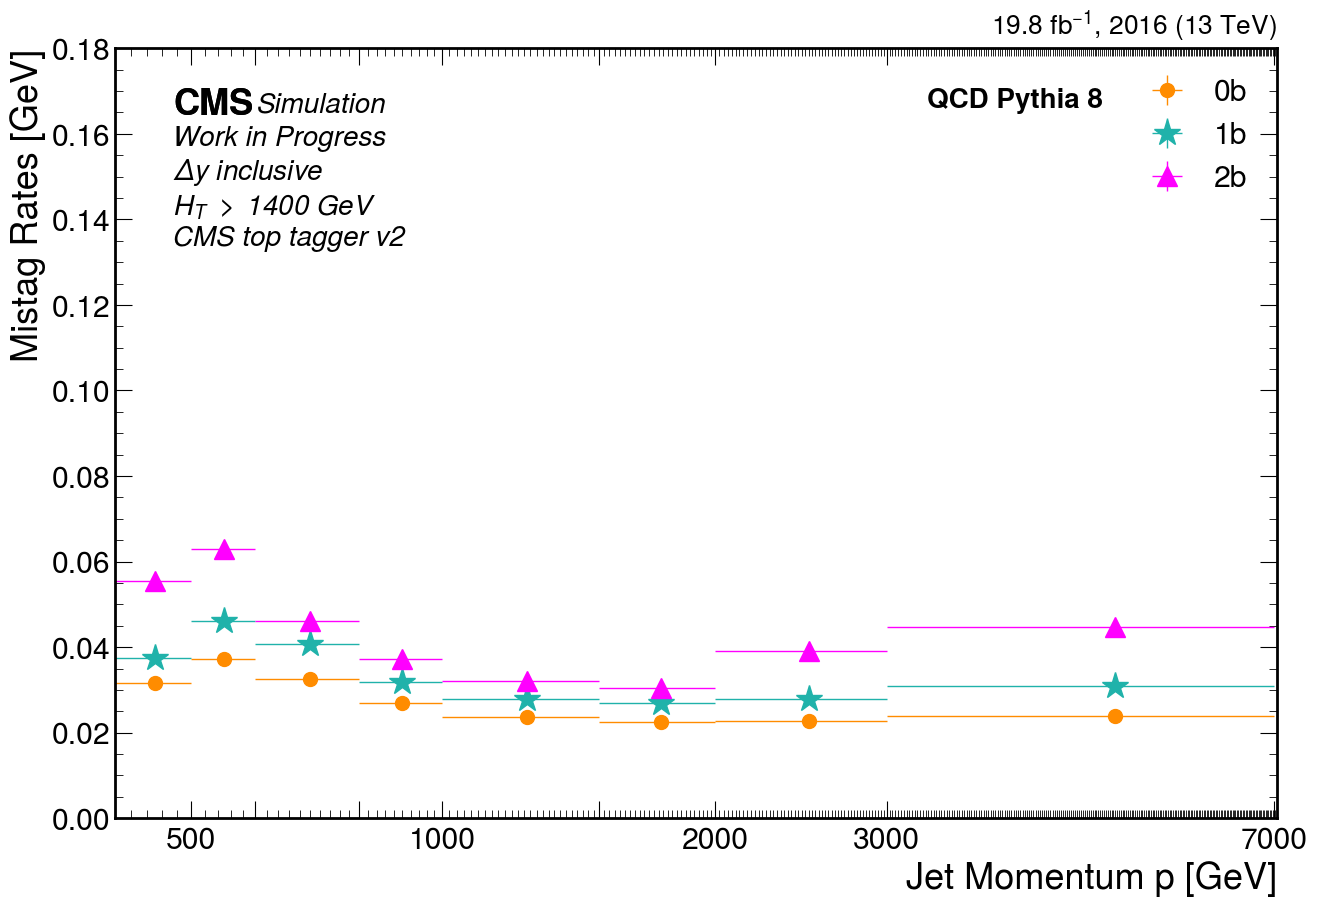

In [12]:
fig, ax = plt.subplots(
    figsize=(15,10),
    sharex=True
)

mistag0b = mistag['0b'].values
mistag1b = mistag['1b'].values
mistag2b = mistag['2b'].values

err0b = np.where(mistag['0berr'].values < 0, 0., mistag['0berr'].values)
err1b = np.where(mistag['1berr'].values < 0, 0., mistag['1berr'].values)
err2b = np.where(mistag['2berr'].values < 0, 0., mistag['2berr'].values)

bins = np.arange(len(mistag0b)+1)
pbins = np.array(mistag['jetp bins'].values)
pbins = np.append(pbins, 10000)

print(mistag0b)
print(pbins)

if '2016' in IOV: Year = '2016'

if runQCD:
    hep.cms.label('Simulation\n', data=True, lumi=luminosity[IOV]/1000, year=Year, fontsize=20, loc=1)
else:
    hep.cms.label('', data=True, lumi=luminosity[IOV]/1000, year=IOV, fontsize=20, loc=2)

# hep.cms.text('Preliminary'+'\n'
#              +r'$\Delta y$ inclusive'+'\n'+r'$H_T\ > 1400\ GeV$'+'\n'
#              +tagger,
#              fontsize=20, loc=2)
if useOldHTcut: HTstr = '950'
else: HTstr = '1400'

btagger=''
if useOldTaggers: btagger='\nCSV b tagger v2'

hep.cms.text('Work in Progress'+'\n'
             +r'$\Delta y$ inclusive'+'\n'+r'$H_T\ >\ '+HTstr+r'\ GeV$'+'\n'
             +tagger+btagger,
             fontsize=20, loc=2)

plt.ylim(bottom = 0.0, top = 0.18)
# plt.ylim(bottom = 0.0, top = 0.26)
plt.xlim(400, 7050)

ColorChoice = {'0':'red', '1':'green', '2':'blue'}
if runQCD: 
    ColorChoice['0'] = 'darkorange'
    ColorChoice['1'] = 'lightseagreen'
    ColorChoice['2'] = 'fuchsia'

hep.histplot(mistag0b, pbins, ax=ax, xerr=True, yerr=err0b, histtype='errorbar', color=ColorChoice['0'], markersize=20)
hep.histplot(mistag1b, pbins, ax=ax, xerr=True, yerr=err1b, histtype='errorbar', color=ColorChoice['1'], marker='*', markersize=20)
hep.histplot(mistag2b, pbins, ax=ax, xerr=True, yerr=err2b, histtype='errorbar', color=ColorChoice['2'], marker='^', markersize=15)

# ---- Optional x-axis scaling ---- #
ax.set_xscale('function', functions=(forward, inverse))
plt.xticks(np.array([400, 500, 600, 800, 1000, 1500, 2000, 3000, 7000]))
ax.set_xticklabels(['', 500, '', '', 1000, '', 2000, 3000, 7000])
ax.set_xlabel('Jet Momentum p [GeV]')
ax.set_ylabel('Mistag Rates [GeV]')
plt.legend(['0b', '1b', '2b'], loc='upper right')

# coffee = plt.text(1.0, 0.87, u"☕",
#               fontsize=50,
#               horizontalalignment='right',
#               verticalalignment='top',
#               transform=ax.transAxes
#              )

if runQCD:
    QCDlabel = plt.text(0.85, 0.95, 'QCD Pythia 8',
                  weight='bold',
                  fontsize=20,
                  horizontalalignment='right',
                  verticalalignment='top',
                  transform=ax.transAxes
                 )
    savefilename = f'../plots/images/pdf/mistagRateQCD/'+IOV+'/mistag_'+tagger.lower().replace('top','').replace(' ','')+oldHTstr+oldTaggerstr+'.pdf'
else:
    savefilename = f'../plots/images/pdf/mistagRate/'+IOV+'/mistag_'+tagger.lower().replace('top','').replace(' ','')+oldHTstr+oldTaggerstr+'.pdf'

# plt.savefig(savefilename)
# plt.savefig(savefilename.replace('pdf', 'png'))

print('saving', savefilename)
print('saving', savefilename.replace('pdf', 'png'))

plt.show()
